<a href="https://colab.research.google.com/github/Sumitha-Git/Capstone-Project/blob/main/Data_Visualization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Loading the Taxis Dataset
import seaborn as sns
df = sns.load_dataset("taxis")
print(df)

                  pickup             dropoff  passengers  distance  fare  \
0    2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0   
1    2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0   
2    2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5   
3    2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0   
4    2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0   
...                  ...                 ...         ...       ...   ...   
6428 2019-03-31 09:51:53 2019-03-31 09:55:27           1      0.75   4.5   
6429 2019-03-31 17:38:00 2019-03-31 18:34:23           1     18.74  58.0   
6430 2019-03-23 22:55:18 2019-03-23 23:14:25           1      4.14  16.0   
6431 2019-03-04 10:09:25 2019-03-04 10:14:29           1      1.12   6.0   
6432 2019-03-13 19:31:22 2019-03-13 19:48:02           1      3.85  15.0   

       tip  tolls  total   color      payment            pickup_zone  \
0     2.15    0

In [ ]:
#Handling Missing Values
missing_values = df.isnull().sum()

print(missing_values)

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [ ]:
columns_with_missing = df.columns[df.isnull().any()]

print("Columns with missing values:")
print(columns_with_missing)
print(df.isnull().sum()[df.isnull().sum() > 0])

Columns with missing values:
Index(['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough',
       'dropoff_borough'],
      dtype='object')
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [ ]:
critical_columns = ['pickup', 'dropoff', 'passengers']
df = df.dropna(subset=critical_columns)

print(df[critical_columns].isnull().sum())

print("Dataset shape:", df.shape)

pickup        0
dropoff       0
passengers    0
dtype: int64
Dataset shape: (6433, 14)


In [ ]:
#Visualizations using Matplotlib/Pandas Plot
import matplotlib.pyplot as plt
import pandas as pd

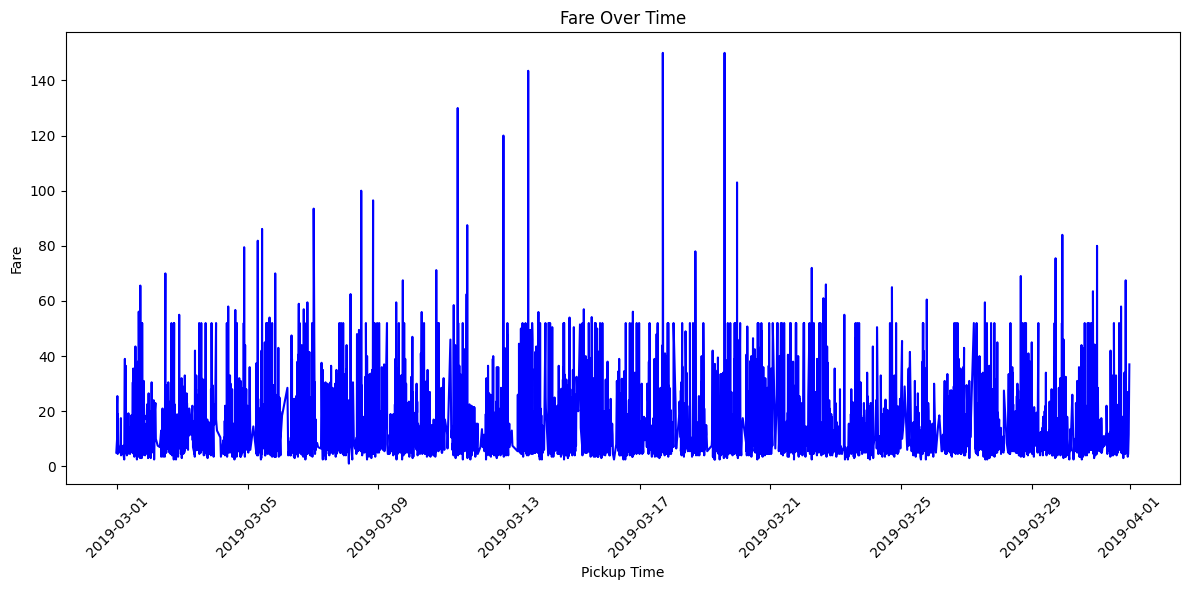

In [ ]:
#Line Chart
df['pickup'] = pd.to_datetime(df['pickup'])

df = df.sort_values('pickup')

plt.figure(figsize=(12, 6))
plt.plot(df['pickup'], df['fare'], color='blue')

plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

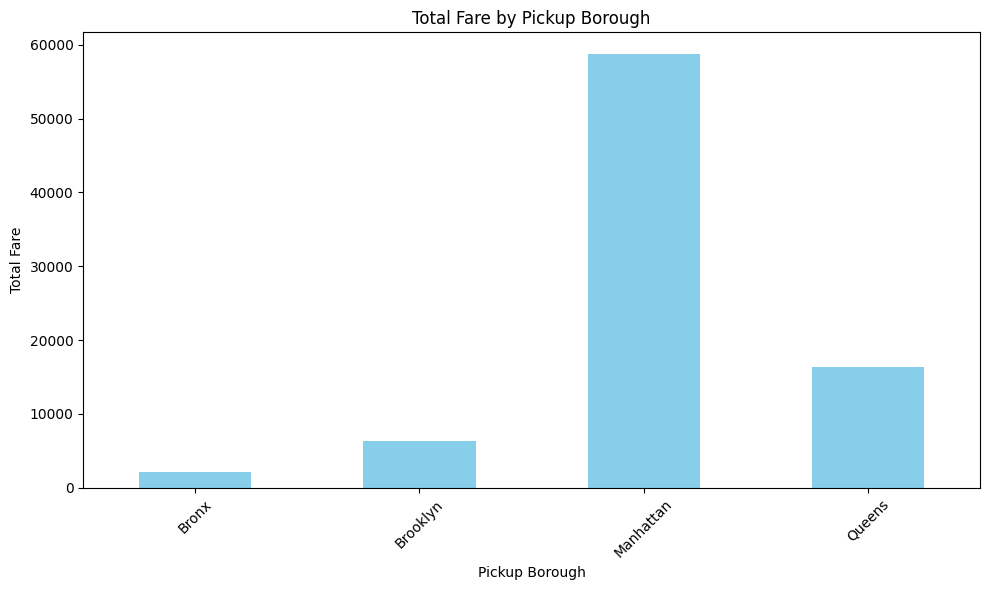

In [ ]:
#Bar Chat
borough_fare = df.groupby('pickup_borough')['fare'].sum()

borough_fare.plot(kind='bar', figsize=(10, 6), color='skyblue')

plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')

plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

In [ ]:
print(df.columns)

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')


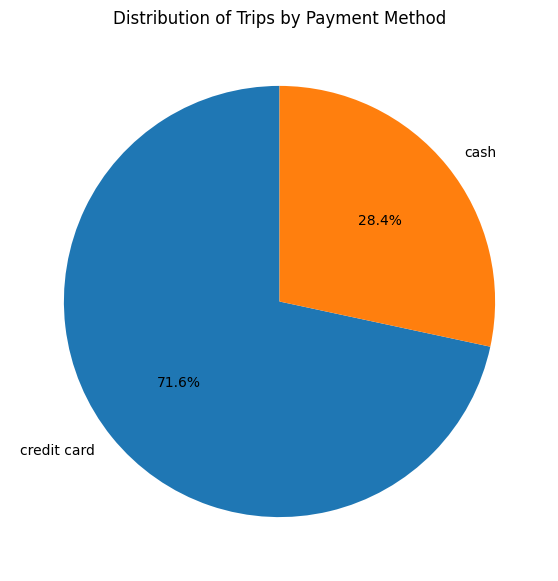

In [ ]:
#Pie Chart
payment_counts = df['payment'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Trips by Payment Method')

plt.show()

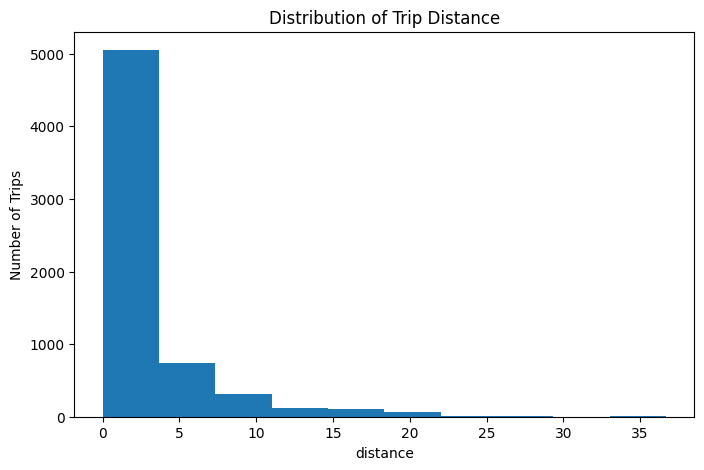

In [ ]:
#Histogram
plt.figure(figsize=(8, 5))

plt.hist(df['distance'], bins=10)

plt.title('Distribution of Trip Distance')
plt.xlabel('distance')
plt.ylabel('Number of Trips')

plt.show()

<Figure size 800x500 with 0 Axes>

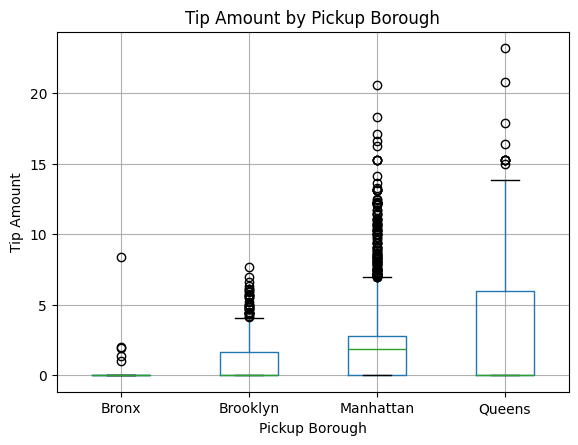

In [ ]:
# Box Plot
plt.figure(figsize=(8, 5))

df.boxplot(
    column='tip',
    by='pickup_borough'
)

plt.title('Tip Amount by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')

plt.suptitle('')   # Removes the extra title

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

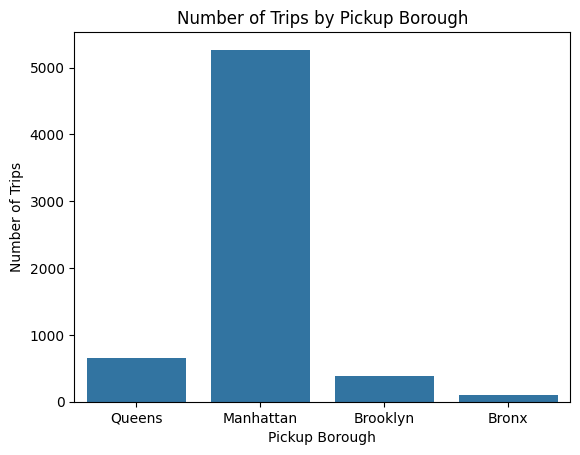

In [ ]:
#Count Plot
sns.countplot(x='pickup_borough', data=df)

plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')

plt.show()

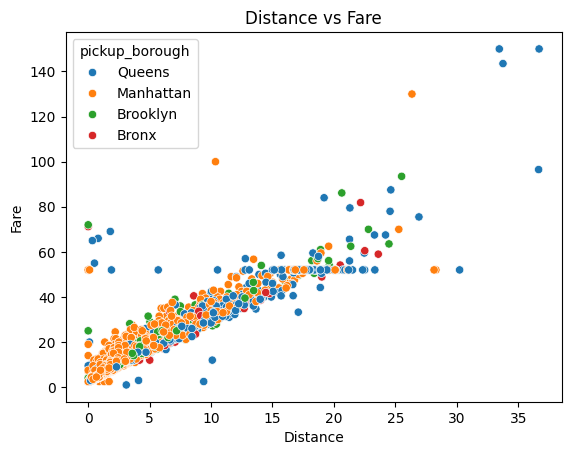

In [ ]:
#Scatter Plot
sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough'
)

plt.title('Distance vs Fare')
plt.xlabel('Distance')
plt.ylabel('Fare')

plt.show()

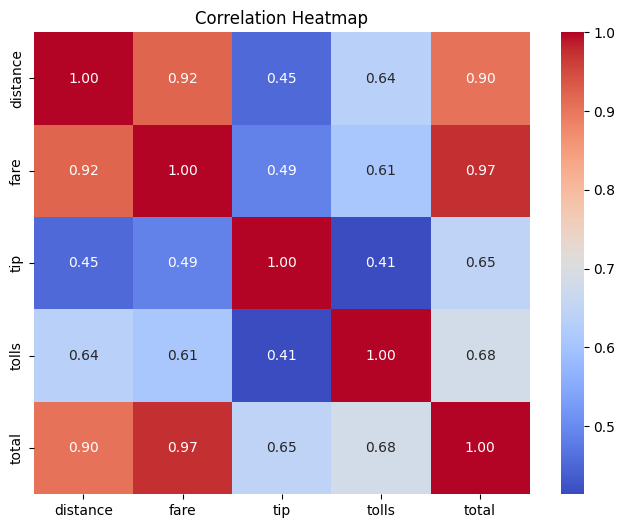

In [ ]:
# Create heatmap
columns = ['distance', 'fare', 'tip', 'tolls', 'total']

correlation = df[columns].corr()


plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

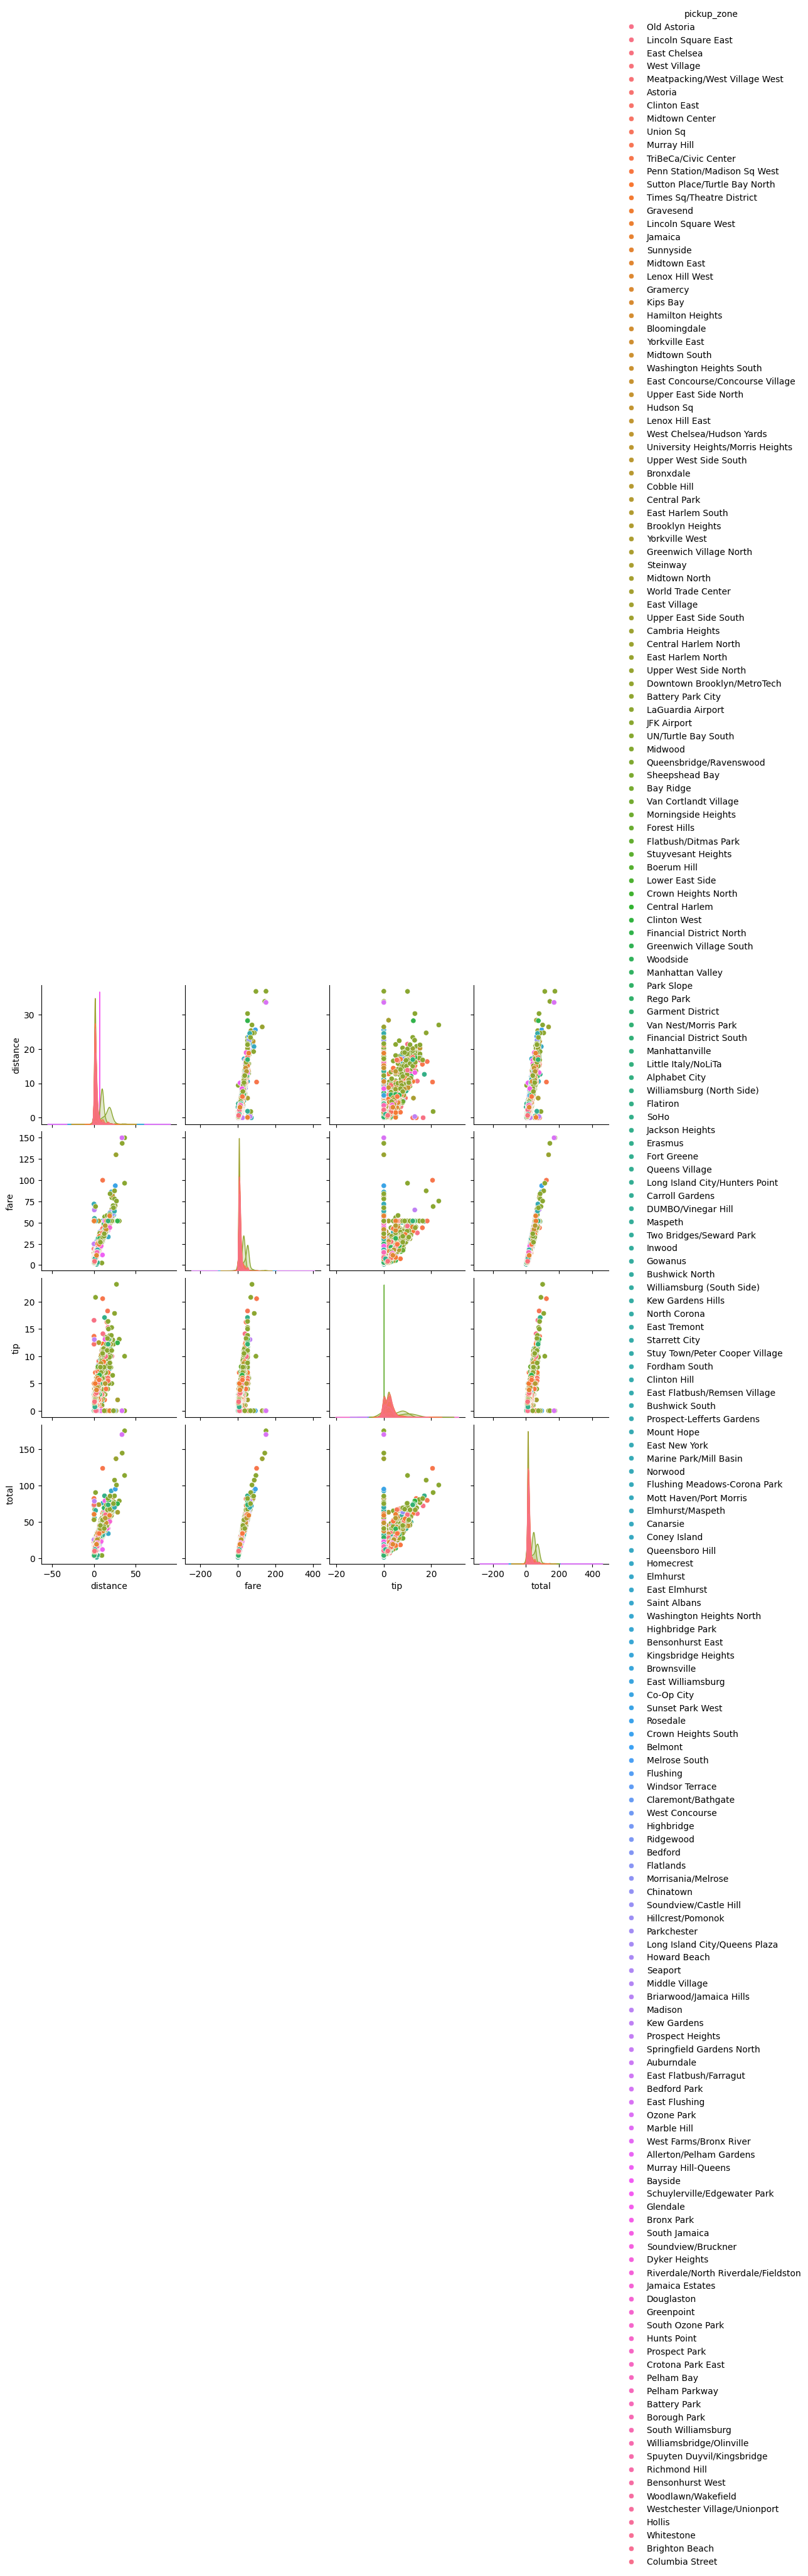

In [ ]:
#Pairplot
sns.pairplot(
    df,
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone'
)

plt.show()

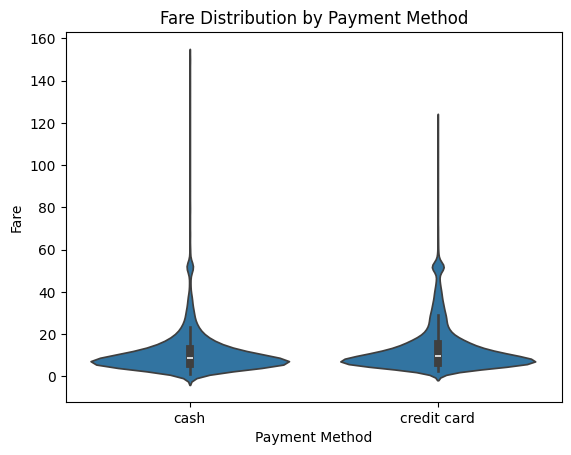

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#Violin Plot
sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')

plt.show()